In [1]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 4.4 MB/s eta 0:00:0000:01


In [2]:
import os
import glob
import random
import logging
from typing import List, Tuple, Optional
import time

import numpy as np
import mne
import wfdb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict

import copy
from collections import OrderedDict
from scipy.special import expit
from sklearn.metrics import accuracy_score

### 1. CONFIGURATION
---

In [3]:
# Path to the root folder containing CHB-MIT patient directories (chb01, chb02, ...)
#DATA_ROOT = "./dataset/chb-mit-1.0.0"
DATA_ROOT = "/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0"

# Optional: folder to cache preprocessed arrays (will be created if it doesn't exist)
PROCESSED_DIR = "/kaggle/working/processed_chb_mit"

# EEG bipolar channels to use (18 channels)
CHANNELS = [
    "FP1-F7", "F7-T7", "T7-P7", "P7-O1",
    "FP1-F3", "F3-C3", "C3-P3", "P3-O1",
    "FP2-F4", "F4-C4", "C4-P4", "P4-O2",
    "FP2-F8", "F8-T8", "T8-P8-1", "P8-O2",
    "FZ-CZ", "CZ-PZ",
]


# Windowing parameters
TIME_WINDOW = 8.0   # seconds per segment
TIME_STEP = 4.0     # seconds between segment starts

# Target sampling frequency after downsampling (CHB-MIT is originally 256 Hz)
TARGET_FS = 128.0

# Non-seizure sampling probability per candidate window (imbalance handling)
P_NON_SEIZURE = 0.01

# Train / test split at patient level
TRAIN_RATIO = 0.8

# Within-training set: validation split
VAL_RATIO = 0.3

# Random seeds for reproducibility
SEED = 2025

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training parameters
LEARNING_RATE = 1e-4
BATCH_SIZE = 256
EPOCHS = 200
EARLY_STOPPING_PATIENCE = 20

### 2. SETUP & UTILITIES 
---

In [4]:
def setup_logging():
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    logging.basicConfig(
        filename=os.path.join(PROCESSED_DIR, "preprocessing.log"),
        level=logging.INFO,
        format="%(asctime)s - %(levelname)s - %(message)s"
    )
    logging.getLogger().addHandler(logging.StreamHandler())


def set_random_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # extra reproducibility settings (optional but recommended)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def list_patient_dirs(root: str) -> List[str]:
    """Return sorted list of patient directory names (e.g. ['chb01', 'chb02', ...])."""
    dirs = sorted(
        d for d in os.listdir(root)
        if os.path.isdir(os.path.join(root, d)) and d.lower().startswith("chb")
    )
    return dirs


def split_patients(patients: List[str], train_ratio: float = TRAIN_RATIO) -> Tuple[List[str], List[str]]:
    """Split patient IDs into train and test sets."""
    n_train = int(round(train_ratio * len(patients)))
    train = sorted(random.sample(patients, n_train))
    test = sorted([p for p in patients if p not in train])
    return train, test


def collect_edf_files(root: str, patient_ids: List[str]) -> List[str]:
    """Collect all .edf files for given patient IDs."""
    files = []
    for pid in patient_ids:
        pattern = os.path.join(root, pid, "*.edf")
        files.extend(sorted(glob.glob(pattern)))
    return files

def processed_files_exist(processed_dir):
    required = [
        "X_train.npy", "y_train.npy",
        "X_val.npy", "y_val.npy",
        "X_test.npy", "y_test.npy",
    ]
    return all(os.path.exists(os.path.join(processed_dir, f)) for f in required)


### 3. Data Processing 
---
#### SEIZURE ANNOTATIONS

In [5]:
def load_seizure_mask(edf_path: str, n_samples: int, fs: float) -> np.ndarray:
    """
    Load seizure annotations for a given EDF file and return a binary mask
    of shape (n_samples,), where 1 indicates seizure.

    This assumes there is an annotation file with extension '.seizures'
    that WFDB can read via rdann.
    """
    mask = np.zeros(n_samples, dtype=np.int8)

    #record_base = os.path.splitext(edf_path)[0]  # includes path, without .edf
    record_base = edf_path
    ann_path = record_base + ".seizures"
    if not os.path.exists(ann_path):
        # No annotation file; treat as all non-seizure
        return mask

    try:
        # WFDB expects the "record name" without extension; can include path
        ann = wfdb.rdann(record_base, "seizures")
    except Exception as e:
        logging.warning(f"Failed to read annotation for {edf_path}: {e}")
        return mask

    # Typical assumption: ann.sample[0], ann.sample[1] are start/end of seizure 1, etc.
    samples = ann.sample
    if len(samples) < 2:
        return mask

    # Pair successive samples as start/end
    for start, end in zip(samples[0::2], samples[1::2]):
        start = max(0, int(start))
        end = min(n_samples, int(end))
        if end > start:
            mask[start:end] = 1

    return mask

#### PER-FILE WINDOWING 

In [6]:

def process_file_to_windows___(
    edf_path: str,
    channels: List[str],
    time_window: float,
    time_step: float,
    target_fs: float,
    p_non_seizure: float
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Read one EDF file, extract sliding windows for the specified channels,
    and return:
        segments: (N_windows_selected, n_channels, n_time_samples)
        labels:   (N_windows_selected,) bool (True = seizure)

    Returns (None, None) if channels are not all present or no windows selected.
    """
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
    except Exception as e:
        logging.warning(f"Failed to read {edf_path}: {e}")
        return None, None

    # Check channel availability
    available = set(raw.ch_names)
    if not all(ch in available for ch in channels):
        logging.info(f"Skipping {edf_path}: required channels missing.")
        return None, None

    raw.pick(channels)
    fs = float(raw.info["sfreq"])
    data = raw.get_data() * 1e6  # convert to microvolts
    n_channels, n_samples = data.shape

    # Build sample-level seizure mask (based on original sampling rate)
    sz_mask = load_seizure_mask(edf_path, n_samples, fs)

    # Downsample to target_fs by simple decimation (integer factor)
    if fs != target_fs:
        factor = int(round(fs / target_fs))
        if factor <= 0:
            raise ValueError(f"Invalid downsampling factor from fs={fs} to {target_fs}")
        data = data[:, ::factor]
        sz_mask = sz_mask[::factor]
        fs = fs / factor
        n_channels, n_samples = data.shape

    # Convert seconds to samples
    win_len = int(round(time_window * fs))
    step = int(round(time_step * fs))

    if n_samples < win_len:
        return None, None

    # Number of windows
    n_windows = 1 + (n_samples - win_len) // step
    if n_windows <= 0:
        return None, None

    # Compute seizure ratio for each window and keep segments in memory
    segs = []
    ratios = []

    for i in range(n_windows):
        start = i * step
        end = start + win_len
        seg = data[:, start:end]
        # Safety check for shape
        if seg.shape[1] != win_len:
            continue
        segs.append(seg)

        win_mask = sz_mask[start:end]
        ratio = win_mask.mean() if len(win_mask) > 0 else 0.0
        ratios.append(ratio)

    segs = np.stack(segs, axis=0)  # (n_windows, n_channels, win_len)
    ratios = np.array(ratios)

    # Select seizure and a subset of non-seizure windows
    idx_pos = np.where(ratios > 0.0)[0]
    idx_neg = np.where(ratios == 0.0)[0]

    selected_indices = []

    if len(idx_pos) > 0:
        selected_indices.append(idx_pos)

    if len(idx_neg) > 0 and p_non_seizure > 0.0:
        n_neg = int(round(p_non_seizure * len(idx_neg)))
        n_neg = max(0, min(n_neg, len(idx_neg)))
        if n_neg > 0:
            chosen_neg = np.random.choice(idx_neg, size=n_neg, replace=False)
            selected_indices.append(chosen_neg)

    if not selected_indices:
        return None, None

    selected_indices = np.concatenate(selected_indices)
    np.random.shuffle(selected_indices)

    segs = segs[selected_indices]
    labels = ratios[selected_indices] > 0.0  # bool: seizure if any seizure in window

    return segs, labels


def detect_gaps_from_data(data: np.ndarray, gap_range_thresh: float = 5e-6):
    """
    data: np.ndarray shape (n_channels, n_samples)
    returns: valid_mask (bool array length n_samples), gap_intervals list of (start_idx, end_idx)
    Gap definition: sample is gap if any channel NaN OR range across channels < threshold.
    """
    n_ch, n_s = data.shape
    # detect NaNs
    nan_mask = np.any(np.isnan(data), axis=0)

    # compute per-sample range across channels
    ch_max = np.max(data, axis=0)
    ch_min = np.min(data, axis=0)
    ch_range = ch_max - ch_min

    gap_mask = (ch_range < gap_range_thresh) | nan_mask  # True => gap sample
    valid_mask = ~gap_mask

    # convert contiguous gap samples to intervals
    gap_intervals = []
    in_gap = False
    start = 0
    for i, g in enumerate(gap_mask):
        if g and not in_gap:
            in_gap = True
            start = i
        elif not g and in_gap:
            in_gap = False
            gap_intervals.append((start, i))
    if in_gap:
        gap_intervals.append((start, n_s))

    return valid_mask, gap_intervals

def preprocess_raw_edf(
    edf_path: str,
    channels: List[str],
    target_fs: float,
    apply_bandpass: bool = True,
):
    """
    Loads EDF, removes dummy/ECG/VNS channels, detects gaps,
    filters, normalizes, downsamples, and returns cleaned data + masks.

    Returns:
        data      : np.ndarray (n_channels, n_samples_clean)
        sz_mask   : np.ndarray (n_samples_clean,)
        fs        : sampling frequency after preprocessing
        gap_info  : dict with stats
    """

    # ------------------------------------
    # 1. Load EDF
    # ------------------------------------
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")

    # ------------------------------------
    # 2. Remove dummy / ECG / VNS signals
    # ------------------------------------
    bad_patterns = ["ECG", "VNS", "-"]
    bad_chs = []

    for ch in raw.ch_names:
        name = ch.strip()
    
        # Dummy channels are literally a single '-'
        if name == "-":
            bad_chs.append(ch)
    
    if len(bad_chs) > 0:
        raw.drop_channels(bad_chs)

    # Keep only required target EEG channels
    available = set(raw.ch_names)
    if not all(ch in available for ch in channels):
        return None, None, None, None

    raw.pick(channels)

    # ------------------------------------
    # Original sampling rate
    # ------------------------------------
    fs = float(raw.info["sfreq"])

    # ------------------------------------
    # 3. Detect gaps BEFORE filtering
    # ------------------------------------
    data_pre = raw.get_data().copy()  # (n_ch, n_samples)
    valid_mask, gap_intervals = detect_gaps_from_data(data_pre, gap_range_thresh=5e-6)

    # Stats for report
    total_samples = len(valid_mask)
    n_gap_samples = np.sum(~valid_mask)

    gap_info = {
        "total_samples": total_samples,
        "gap_samples": int(n_gap_samples),
        "gap_percentage": float(n_gap_samples / total_samples * 100),
        "num_gaps": len(gap_intervals),
        "gap_intervals": gap_intervals,
    }

    # Remove gaps
    data_pre = data_pre[:, valid_mask]

    # ------------------------------------
    # 4. Load seizure mask and remove gap samples in sync
    # ------------------------------------
    sz_mask_full = load_seizure_mask(edf_path, total_samples, fs)
    sz_mask = sz_mask_full[valid_mask]

    # ------------------------------------
    # 5. Band-pass filter (optional)
    # ------------------------------------
    if apply_bandpass:
        raw_filt = mne.io.RawArray(data_pre, raw.info.copy())
        raw_filt.filter(0.5, 40.0, method="fir", verbose="ERROR")
        data_pre = raw_filt.get_data()

    # ------------------------------------
    # 6. Normalization (z-score per channel)
    # ------------------------------------
    data_pre = (data_pre - np.mean(data_pre, axis=1, keepdims=True)) / (
        np.std(data_pre, axis=1, keepdims=True) + 1e-6
    )

    # ------------------------------------
    # 7. Downsample
    # ------------------------------------
    if fs != target_fs:
        factor = int(round(fs / target_fs))
        data_pre = data_pre[:, ::factor]
        sz_mask = sz_mask[::factor]
        fs = fs / factor

    return data_pre, sz_mask.astype(np.int8), fs, gap_info


def process_file_to_windows(
    edf_path: str,
    channels: List[str],
    time_window: float,
    time_step: float,
    target_fs: float,
    p_non_seizure: float
):
    """
    Full preprocessing + sliding window extraction.
    """

    # ------------------------------------
    # Use unified preprocessing function
    # ------------------------------------
    result = preprocess_raw_edf(edf_path, channels, target_fs)

    if result[0] is None:
        return None, None

    data, sz_mask, fs, gap_info = result
    n_channels, n_samples = data.shape

    # ------------------------------------
    # Sliding windows
    # ------------------------------------
    win_len = int(round(time_window * fs))
    step = int(round(time_step * fs))

    if n_samples < win_len:
        return None, None

    n_windows = 1 + (n_samples - win_len) // step
    segs = []
    ratios = []

    for i in range(n_windows):
        s = i * step
        e = s + win_len
        seg = data[:, s:e]
        segs.append(seg)
        ratios.append(sz_mask[s:e].mean())

    segs = np.stack(segs)
    ratios = np.array(ratios)

    # ------------------------------------
    # Select positive and negative windows
    # ------------------------------------
    idx_pos = np.where(ratios > 0.0)[0]
    idx_neg = np.where(ratios == 0.0)[0]
    selected = []

    if len(idx_pos) > 0:
        selected.append(idx_pos)

    if len(idx_neg) > 0:
        n_neg = int(p_non_seizure * len(idx_neg))
        chosen = np.random.choice(idx_neg, n_neg, replace=False)
        selected.append(chosen)

    if not selected:
        return None, None

    selected = np.concatenate(selected)
    np.random.shuffle(selected)

    segs = segs[selected]
    labels = ratios[selected] > 0.0

    return segs, labels


 #### DATASET BUILDING

In [7]:
def build_dataset_from_files(files: List[str]) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Build dataset (segments, labels) from a list of EDF files.

    Returns:
        X: (N_segments, n_channels, n_time_samples)
        y: (N_segments,) bool
        fs: target sampling frequency used
    """
    all_segments = []
    all_labels = []

    for idx, fpath in enumerate(files):
        logging.info(f"[{idx + 1}/{len(files)}] Processing {fpath}")
        segs, labels = process_file_to_windows(
            fpath,
            channels=CHANNELS,
            time_window=TIME_WINDOW,
            time_step=TIME_STEP,
            target_fs=TARGET_FS,
            p_non_seizure=P_NON_SEIZURE
        )
        if segs is None:
            continue

        all_segments.append(segs)
        all_labels.append(labels)

    if not all_segments:
        raise RuntimeError("No segments were extracted from the provided files.")

    X = np.concatenate(all_segments, axis=0)
    y = np.concatenate(all_labels, axis=0)

    logging.info(f"Built dataset: X.shape={X.shape}, y.shape={y.shape}, "
                 f"seizure_ratio={y.mean():.4f}")

    return X, y.astype(bool), TARGET_FS

### 4. MODEL DEFINITION 
---

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class EEGCNN(nn.Module):
    """
    21 CNN for EEG windows.

    Expects input of shape: (batch_size, n_channels, n_time)
    Returns raw logits of shape: (batch_size, 1)
    """

    def __init__(self, in_channels):
        super().__init__()
        
        # 1D Convolutional Blocks
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool1d(2)
        
        self.conv5 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.conv6 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool1d(2)
        
        # Classification Head
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1) # Final logic (binary)

    def forward(self, x):
        # x: (B, C, T)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)
        
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool3(x)
        
        # Global Average Pooling
        x = self.global_pool(x).squeeze(-1) # (B, 256)
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # (B, 1)
        
        return x.squeeze(1)

### 5. TRAINING & EVALUATION 
---

In [9]:
def train_and_evaluate(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray
):
    """
    Train the CNN (PyTorch) and evaluate on validation and test sets.
    Prints Keras-style logs and records training curves.
    Assumes EEGCNN.forward returns logits of shape (B,)
    and y_* are 0/1 arrays.
    """

    # ---- prepare tensors & loaders ----
    X_train_t = torch.from_numpy(X_train).float()  # (N,C,T)
    X_val_t   = torch.from_numpy(X_val).float()
    X_test_t  = torch.from_numpy(X_test).float()

    y_train_t = torch.from_numpy(y_train.astype(np.float32))
    y_val_t   = torch.from_numpy(y_val.astype(np.float32))
    y_test_t  = torch.from_numpy(y_test.astype(np.float32))

    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds   = TensorDataset(X_val_t, y_val_t)
    test_ds  = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # ---- model, loss, optimizer, scheduler ----
    model = EEGCNN(in_channels=len(CHANNELS)).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
        verbose=True
    )

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    # history containers
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    lrs = []

    # ---- training loop ----
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()

        # ----- TRAIN -----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for step, (xb, yb) in enumerate(train_loader, start=1):
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)                  # (B,)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

            # accuracy
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

        train_loss = running_loss / total
        train_acc = correct / total

        # ----- VALIDATION -----
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)
                val_running_loss += loss.item() * xb.size(0)

                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                val_correct += (preds == yb).sum().item()
                val_total += yb.numel()

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        # ---- scheduler + history ----
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        lrs.append(current_lr)

        epoch_time = time.time() - epoch_start
        steps_per_epoch = len(train_loader)
        ms_per_step = (epoch_time / steps_per_epoch) * 1000

        # Keras-style line
        print(f"{epoch}/{EPOCHS} - {epoch_time:.0f}s - {ms_per_step:.0f}ms/step "
              f"- accuracy: {train_acc:.4f} - loss: {train_loss:.4f} "
              f"- val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f} "
              f"- lr: {current_lr:.2e}")

        # ---- early stopping ----
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # ---- evaluation helper ----
    def eval_on_loader(loader):
        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(DEVICE)
                logits = model(xb)              # (B,)
                probs = torch.sigmoid(logits)   # (B,)
                all_probs.append(probs.cpu().numpy())
                all_labels.append(yb.cpu().numpy())
        all_probs = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        preds = (all_probs > 0.5).astype(int)
        return all_labels, all_probs, preds

    # ---- validation metrics ----
    y_val_true, y_val_probs, y_val_pred = eval_on_loader(val_loader)
    print("=== Validation report (threshold=0.5) ===")
    print(classification_report(y_val_true, y_val_pred, digits=4))
    try:
        val_auc = roc_auc_score(y_val_true, y_val_probs)
        print(f"Validation ROC AUC: {val_auc:.4f}")
    except ValueError:
        print("Validation ROC AUC: not defined (only one class present).")

    # ---- test metrics ----
    y_test_true, y_test_probs, y_test_pred = eval_on_loader(test_loader)
    print("=== Test report (threshold=0.5) ===")
    print(classification_report(y_test_true, y_test_pred, digits=4))
    try:
        test_auc = roc_auc_score(y_test_true, y_test_probs)
        print(f"Test ROC AUC: {test_auc:.4f}")
    except ValueError:
        print("Test ROC AUC: not defined (only one class present).")

    # ---- PLOTS: training curves ----
    epochs_range = range(1, len(train_losses) + 1)

    # Loss curves
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, train_losses, label="Train loss")
    plt.plot(epochs_range, val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training / validation loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Accuracy curves (optional but useful)
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, train_accs, label="Train accuracy")
    plt.plot(epochs_range, val_accs, label="Val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training / validation accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # LR curve
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, lrs)
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("Learning rate schedule")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs,
        "lr": lrs,
    }

    return model, history


 ### 6. MAIN PIPELINE
 ---

In [10]:
# 0. config
setup_logging()
set_random_seeds(SEED)

In [11]:
# 1. Build train & test datasets
if processed_files_exist(PROCESSED_DIR):
    print("📂 Loading cached preprocessed dataset...")

    X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
    y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
    X_val   = np.load(os.path.join(PROCESSED_DIR, "X_val.npy"))
    y_val   = np.load(os.path.join(PROCESSED_DIR, "y_val.npy"))
    X_test  = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
    y_test  = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
else:
    # 1) Get all patients and all EDF files
    patients = list_patient_dirs(DATA_ROOT)
    if not patients:
        raise RuntimeError(f"No patient directories found under {DATA_ROOT}")

    # Collect ALL EDF files from ALL patients
    all_files = collect_edf_files(DATA_ROOT, patients)
    print(f"Total EDF files: {len(all_files)}")

    # 2) Build one big dataset (all patients concatenated)
    print("Building full dataset from all patients...")
    X_all, y_all, fs_all = build_dataset_from_files(all_files)

    assert fs_all == TARGET_FS
    print(f"Full dataset: X_all = {X_all.shape}, y_all = {y_all.shape}")

    # 3) Split into train / val / test on the SEGMENT level
    #    Keep global proportions consistent with your old TRAIN_RATIO/VAL_RATIO:
    #    - First: TRAIN vs TEST using TRAIN_RATIO
    #    - Then: split TRAIN part into (train, val) with VAL_RATIO
    TEST_RATIO = 1.0 - TRAIN_RATIO

    # 3a) Train+Val vs Test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_all,
        y_all,
        test_size=TEST_RATIO,
        stratify=y_all,
        random_state=SEED,
    )

    # 3b) Train vs Val (inside the previous TRAIN part)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=VAL_RATIO,
        stratify=y_temp,
        random_state=SEED,
    )

    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
    print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

    # 4) Save splits
    np.save(os.path.join(PROCESSED_DIR, "X_train.npy"), X_train)
    np.save(os.path.join(PROCESSED_DIR, "y_train.npy"), y_train)
    np.save(os.path.join(PROCESSED_DIR, "X_val.npy"), X_val)
    np.save(os.path.join(PROCESSED_DIR, "y_val.npy"), y_val)
    np.save(os.path.join(PROCESSED_DIR, "X_test.npy"), X_test)
    np.save(os.path.join(PROCESSED_DIR, "y_test.npy"), y_test)
    print(f"Datasets saved under: {PROCESSED_DIR}")

    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
    print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

[1/686] Processing /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_01.edf


Total EDF files: 686
Building full dataset from all patients...
Creating RawArray with float64 data, n_channels=18, n_times=921596
    Range : 0 ... 921595 =      0.000 ...  3599.980 secs
Ready.


[2/686] Processing /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_02.edf


Creating RawArray with float64 data, n_channels=18, n_times=921597
    Range : 0 ... 921596 =      0.000 ...  3599.984 secs
Ready.


[3/686] Processing /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_03.edf


...

Creating RawArray with float64 data, n_channels=18, n_times=921598
    Range : 0 ... 921597 =      0.000 ...  3599.988 secs
Ready.


[686/686] Processing /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb24/chb24_22.edf


Creating RawArray with float64 data, n_channels=18, n_times=272724
    Range : 0 ... 272723 =      0.000 ...  1065.324 secs
Ready.


Built dataset: X.shape=(11145, 18, 1024), y.shape=(11145,), seizure_ratio=0.2881


Full dataset: X_all = (11145, 18, 1024), y_all = (11145,)
X_train: (6241, 18, 1024), y_train: (6241,)
X_val:   (2675, 18, 1024), y_val:   (2675,)
X_test:  (2229, 18, 1024), y_test:  (2229,)
Datasets saved under: /kaggle/working/processed_chb_mit
X_train: (6241, 18, 1024), y_train: (6241,)
X_val:   (2675, 18, 1024), y_val:   (2675,)
X_test:  (2229, 18, 1024), y_test:  (2229,)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


1/200 - 4s - 141ms/step - accuracy: 0.2881 - loss: 0.7108 - val_accuracy: 0.2882 - val_loss: 0.7023 - lr: 1.00e-04
2/200 - 2s - 94ms/step - accuracy: 0.5518 - loss: 0.6841 - val_accuracy: 0.7880 - val_loss: 0.6421 - lr: 1.00e-04
3/200 - 2s - 95ms/step - accuracy: 0.7996 - loss: 0.5545 - val_accuracy: 0.8262 - val_loss: 0.4729 - lr: 1.00e-04
4/200 - 2s - 96ms/step - accuracy: 0.8253 - loss: 0.4284 - val_accuracy: 0.8299 - val_loss: 0.4014 - lr: 1.00e-04
5/200 - 2s - 95ms/step - accuracy: 0.8435 - loss: 0.3953 - val_accuracy: 0.8464 - val_loss: 0.3843 - lr: 1.00e-04
6/200 - 2s - 96ms/step - accuracy: 0.8483 - loss: 0.3853 - val_accuracy: 0.8467 - val_loss: 0.3737 - lr: 1.00e-04
7/200 - 2s - 96ms/step - accuracy: 0.8558 - loss: 0.3726 - val_accuracy: 0.8564 - val_loss: 0.3619 - lr: 1.00e-04
8/200 - 2s - 96ms/step - accuracy: 0.8600 - loss: 0.3616 - val_accuracy: 0.8598 - val_loss: 0.3526 - lr: 1.00e-04
9/200 - 2s - 96ms/step - accuracy: 0.8620 - loss: 0.3559 - val_accuracy: 0.8639 - val_l

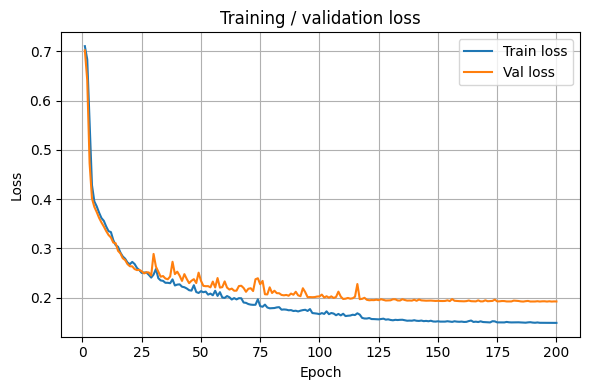

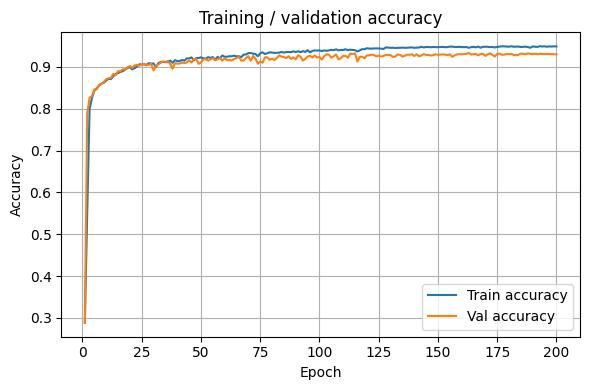

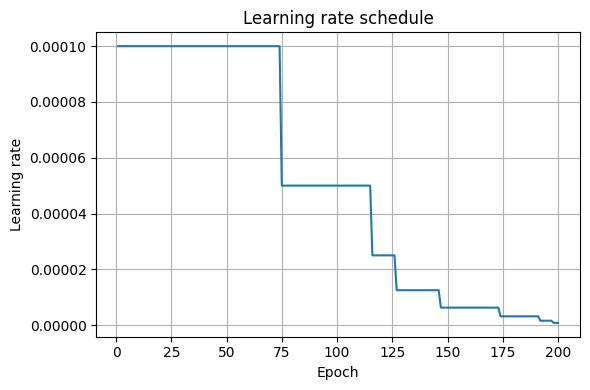

In [12]:
# 2. Train and evaluate model
model, history = train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test)

In [13]:
# 3. Save model and splits
model_path = os.path.join(PROCESSED_DIR, "seizure_cnn_model.pth")
torch.save(model.state_dict(), model_path)

print(f"Model weights saved to: {model_path}")

Model weights saved to: /kaggle/working/processed_chb_mit/seizure_cnn_model.pth


# Stage 3 — SNN conversion & inference

In [14]:
baseline = EEGCNN(in_channels=len(CHANNELS))
baseline.load_state_dict(torch.load(model_path, map_location=DEVICE))
baseline.to(DEVICE)
baseline.eval()

snn_model = copy.deepcopy(baseline)
snn_model.eval()

def max_activation(model, X_sample, DEVICE):
    act = {}
    def hook_output(name):
        def hook(model, input, output):
            output = output.detach().abs()
            val = torch.quantile(output.detach().abs(), 0.999).item()
            act[name] = max(1e-5,val)
        return hook

    hooks = []
    
    for name, m in model.named_modules():
        if isinstance(m, (nn.Conv1d, nn.Linear)):
            hooks.append(m.register_forward_hook(hook_output(name)))
    try:
        X_tensor = torch.tensor(X_sample).float().to(DEVICE)
        input_max = torch.quantile(X_tensor.abs(), 0.999).item()
        with torch.no_grad():
            model(X_tensor)
    finally:
        for h in hooks: 
            h.remove()
    return act, input_max

max_activations, input_max = max_activation(baseline, X_test[:200], DEVICE)

layer_names = ['conv1', 'conv2', 'conv3', 'conv4', 'conv5', 'conv6', 'fc1', 'fc2', 'fc3']
prev_max = input_max

with torch.no_grad():
    for name in layer_names:
        layer = dict(snn_model.named_modules())[name]
        curr_max = max_activations[name]
 
        layer.weight.data *= prev_max / curr_max
        if layer.bias is not None:
            layer.bias.data *= 1.0 / curr_max
        prev_max = curr_max

class IFNeuron(nn.Module):
    def __init__(self, th=1.0):
        super().__init__()
        self.th = th
    
    def forward(self, x, mem):
        mem += x
        spike = (mem >= self.th).float()
        mem = mem - spike * self.th # Soft reset
        return spike, mem

class SNN_Norm(nn.Module):
    def __init__(self, normalized_model):
        super().__init__()
        self.conv1 = normalized_model.conv1
        self.conv2 = normalized_model.conv2
        self.pool1 = normalized_model.pool1
        self.conv3 = normalized_model.conv3
        self.conv4 = normalized_model.conv4
        self.pool2 = normalized_model.pool2
        self.conv5 = normalized_model.conv5
        self.conv6 = normalized_model.conv6
        self.pool3 = normalized_model.pool3
        self.global_pool = normalized_model.global_pool
        self.fc1 = normalized_model.fc1
        self.fc2 = normalized_model.fc2
        self.fc3 = normalized_model.fc3

        self.neurons = nn.ModuleDict({name: IFNeuron(th=1.0) for name in ['conv1','conv2','conv3','conv4','conv5','conv6','fc1','fc2']})
        
    def forward(self, x_analog, time_steps):
        mem = {k: 0.0 for k in self.neurons.keys()}
        mem_out = 0.0
        outputs = []
        
        for t in range(time_steps):
            x = x_analog 
            x = self.conv1(x)
            x, mem['conv1'] = self.neurons['conv1'](x, mem['conv1'])
            x = self.conv2(x)
            x, mem['conv2'] = self.neurons['conv2'](x, mem['conv2'])
            x = self.pool1(x)
            
            x = self.conv3(x)
            x, mem['conv3'] = self.neurons['conv3'](x, mem['conv3'])
            x = self.conv4(x)
            x, mem['conv4'] = self.neurons['conv4'](x, mem['conv4'])
            x = self.pool2(x)
            
            x = self.conv5(x)
            x, mem['conv5'] = self.neurons['conv5'](x, mem['conv5'])
            x = self.conv6(x)
            x, mem['conv6'] = self.neurons['conv6'](x, mem['conv6'])
            x = self.pool3(x)
            
            x = self.global_pool(x).squeeze(-1)
            x = self.fc1(x)
            x, mem['fc1'] = self.neurons['fc1'](x, mem['fc1'])
            x = self.fc2(x)
            x, mem['fc2'] = self.neurons['fc2'](x, mem['fc2'])
                
            mem_out += self.fc3(x) 
            outputs.append(mem_out)
        return torch.stack(outputs)


snn = SNN_Norm(snn_model).to(DEVICE)


def inference(model, X_test, time_steps=50, batch_size=32):
    model.eval()
    logits = []
    
    X_scaled = X_test / input_max
    
    print(f"Inference: {len(X_test)} samples, {time_steps} steps")
    
    with torch.no_grad():
        for i in range(0, len(X_test), batch_size):
            batch = torch.tensor(X_scaled[i:i+batch_size]).float().to(DEVICE)
            voltage = model(batch, time_steps)
            
            # Recover logits
            final_logits = (voltage[-1].squeeze(-1) / time_steps) * max_activations['fc3']
            logits.extend(final_logits.cpu().numpy())
            
    logits_ = np.array(logits)
    probs = expit(logits_)
    return probs

probs = inference(snn, X_test, time_steps=50)

b_acc, b_th, thresholds = 0.0, 0.5, np.arange(0.1, 0.95, 0.05)

for th in thresholds:
    preds_adj = (probs > th).astype(int)
    acc = accuracy_score(y_test, preds_adj)
    
    if acc > b_acc:
        b_acc = acc
        b_th = th

print(f"\nBest Threshold: {b_th:.2f}")
print(f"Best Accuracy:  {b_acc:.4f}")

final_preds = (probs > b_th).astype(int)
print("\n=== SNN RESULTS ===")
print(classification_report(y_test, final_preds, digits=4))
print(f"ROC AUC: {roc_auc_score(y_test, probs):.4f}")

Inference: 2229 samples, 50 steps

Best Threshold: 0.30
Best Accuracy:  0.9269

=== SNN RESULTS ===
              precision    recall  f1-score   support

       False     0.9263    0.9748    0.9500      1587
        True     0.9284    0.8084    0.8643       642

    accuracy                         0.9269      2229
   macro avg     0.9274    0.8916    0.9071      2229
weighted avg     0.9270    0.9269    0.9253      2229

ROC AUC: 0.9569
